# Run Existing Models

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from pathlib import Path

import importlib
import joblib
import numpy as np
import pandas as pd

import src.constants as constants
import src.data_processing.dataframe as dataframe
import src.data_processing.preprocessing as preprocessing
import src.features.events as events
import src.features.features as features
import src.pipeline.dataset as dataset
import src.pipeline.pipeline as pipeline
import src.pipeline.visualization as visualization
import src.model.models as models
import src.model.io as models_io
import src.utils as utils

In [3]:
# Functions need to be reloaded after editing in .py files
importlib.reload(constants)
importlib.reload(dataframe)
importlib.reload(preprocessing)
importlib.reload(events)
importlib.reload(features)
importlib.reload(dataset)
importlib.reload(pipeline)
importlib.reload(visualization)
importlib.reload(models)
importlib.reload(models_io)
importlib.reload(utils)

<module 'src.utils' from 'c:\\Users\\samif\\Forward Football\\pass_detection\\src\\utils.py'>

In [4]:
from src.pipeline.pipeline import pipeline

save_path = Path("../data/processed/all_matches.joblib")

save_path.parent.mkdir(parents=True, exist_ok=True)

if save_path.exists():
    print("Loading preprocessed matches...")
    all_matches = joblib.load(save_path)
else:
    print("Preprocessing matches...")
    all_matches = pipeline()
    joblib.dump(all_matches, save_path)
    

Loading preprocessed matches...


In [5]:
# Removed features based on negative feature importance using validation data

neg_cols = [
    "ball_movement_directness",
    "ball_curve_ratio",
    "speed_max_per_path_length",
    "acc_max",
    "acc_min",
    "acc_abs_max",
    "acc_abs_mean",    
    "closest_player_start_end_valid",
    "closest_team_start_end_valid",
    "streak_center",
    "streak_std",
    "closest_team_share_max",
    "own_opposition_ratio_near_center",
    "dist_player_change_std",
    "dist_player_change_max",
    "displacement_std",
    "displacement_var",
    "own_players_near_mean",
    "oppo_players_near_mean",
    "speed_std",
    "direction_std",
    "nearest_dist_opening",
    "nearest_dist_closing",
    "nearest_dist_pass_arc",
    "dist_player_change_min",
    "streak_end",
    "ball_speed_center",
]

for match in all_matches:
    match["X"] = match["X"].drop(columns=neg_cols, errors="ignore")

In [6]:
from sklearn.model_selection import train_test_split
from src.constants import RANDOM_STATE 

train_matches, temp_matches = train_test_split(all_matches, test_size=0.2, random_state=RANDOM_STATE)

val_matches, test_matches = train_test_split(temp_matches, test_size=0.5, random_state=RANDOM_STATE)

In [7]:
from src.pipeline.dataset import apply_nan_mask_with_meta

# TRAIN
for m in train_matches:
    m["X"], m["y"], m["meta"] = apply_nan_mask_with_meta(
        m["X"], 
        m["y"], 
        m["meta"]
    )

X_train = np.concatenate([m["X"] for m in train_matches])
y_train = np.concatenate([m["y"] for m in train_matches])
meta_train = pd.concat([m["meta"] for m in train_matches], ignore_index=True)

# Groups for RandomSearchCV - 1 full match is a Cross Validation
groups = np.concatenate([np.full(len(m["y"]), i) for i, m in enumerate(train_matches)])

# VALIDATION
for m in val_matches:
    m["X"], m["y"], m["meta"] = apply_nan_mask_with_meta(
        m["X"], 
        m["y"], 
        m["meta"]
    )

X_val = np.concatenate([m["X"] for m in val_matches])
y_val = np.concatenate([m["y"] for m in val_matches])
meta_val = pd.concat([m["meta"] for m in val_matches], ignore_index=True)


# TEST
for m in test_matches:
    m["X"], m["y"], m["meta"] = apply_nan_mask_with_meta(
        m["X"], 
        m["y"], 
        m["meta"]
    )

X_test = np.concatenate([m["X"] for m in test_matches])
y_test = np.concatenate([m["y"] for m in test_matches])
meta_test = pd.concat([m["meta"] for m in test_matches], ignore_index=True)

# Load Model

In [8]:
LR = "Logistic Regression"
SVM = "SVM"
DT = "Decision Tree"
RF = "Random Forest"
XGB = "XGBoost"
MLP = "MLP"

In [9]:
model = models_io.load_model_package(LR)

Model loaded from: ..\saved_models\Logistic Regression.joblib


Logistic Regression - Final results:
              precision    recall  f1-score   support

           0       0.83      0.60      0.69      5024
           1       0.61      0.84      0.70      3757

    accuracy                           0.70      8781
   macro avg       0.72      0.72      0.70      8781
weighted avg       0.74      0.70      0.70      8781



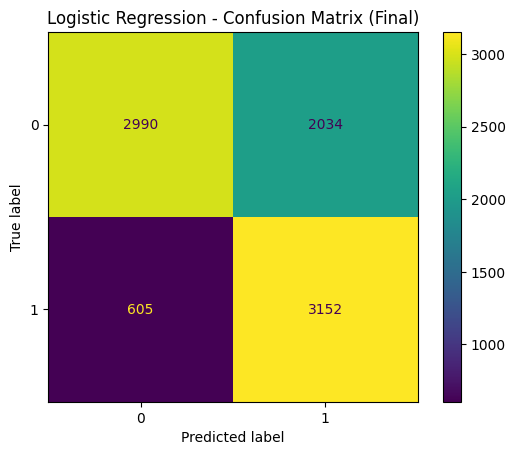

{'accuracy': 0.699464753444938,
 'precision_0': 0.8317107093184979,
 'recall_0': 0.5951433121019108,
 'f1_0': 0.693815987933635,
 'precision_1': 0.607790204396452,
 'recall_1': 0.8389672611125898,
 'f1_1': 0.7049088672704908,
 'macro_precision': 0.719750456857475,
 'macro_recall': 0.7170552866072504,
 'macro_f1': 0.6993624276020629,
 'weighted_precision': 0.7359050679345864,
 'weighted_recall': 0.699464753444938,
 'weighted_f1': 0.6985621384482196}

In [10]:
models.final_evaluation(model["model"], model["model_name"], X_test, y_test, model["threshold"])